In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
result = pd.read_csv("results.csv")
result.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [3]:
goals = pd.read_csv("goalscorers.csv")
goals.head()

,date,home_team,away_team,team,scorer,minute,own_goal,penalty
0,1916-07-02,Chile,Uruguay,Uruguay,José Piendibene,44.0,False,False
1,1916-07-02,Chile,Uruguay,Uruguay,Isabelino Gradín,55.0,False,False
2,1916-07-02,Chile,Uruguay,Uruguay,Isabelino Gradín,70.0,False,False
3,1916-07-02,Chile,Uruguay,Uruguay,José Piendibene,75.0,False,False
4,1916-07-06,Argentina,Chile,Argentina,Alberto Ohaco,2.0,False,False


In [4]:
former = pd.read_csv("former_names.csv")
former.head()

,current,former,start_date,end_date
0,Benin,Dahomey,1959-11-08,1975-11-30
1,Burkina Faso,Upper Volta,1960-04-14,1984-08-04
2,Curaçao,Netherlands Antilles,1957-03-03,2010-10-10
3,Czechoslovakia,Bohemia,1903-04-05,1919-01-01
4,Czechoslovakia,Bohemia and Moravia,1939-01-01,1945-05-01


In [5]:
shoot = pd.read_csv("shootouts.csv")
shoot.head()

,date,home_team,away_team,winner,first_shooter
0,1967-08-22,India,Taiwan,Taiwan,NaN
1,1971-11-14,South Korea,Vietnam Republic,South Korea,NaN
2,1972-05-07,South Korea,Iraq,Iraq,NaN
3,1972-05-17,Thailand,South Korea,South Korea,NaN
4,1972-05-19,Thailand,Cambodia,Thailand,NaN


In [6]:
result.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49520 entries, 0 to 49519
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        49520 non-null  object 
 1   home_team   49520 non-null  object 
 2   away_team   49520 non-null  object 
 3   home_score  49518 non-null  float64
 4   away_score  49518 non-null  float64
 5   tournament  49520 non-null  object 
 6   city        49520 non-null  object 
 7   country     49520 non-null  object 
 8   neutral     49520 non-null  bool   
dtypes: bool(1), float64(2), object(6)
memory usage: 3.1+ MB


In [7]:
result.describe()

,home_score,away_score
count,49518.000000,49518.000000
mean,1.757179,1.182338
std,1.773730,1.401927
min,0.000000,0.000000
25%,1.000000,0.000000
50%,1.000000,1.000000
75%,2.000000,2.000000
max,31.000000,21.000000


## 2. Data Cleaning

Before starting the analysis, the datasets must be cleaned to ensure data quality and consistency. This step includes:

- Checking for missing values.
- Removing duplicates.
- Converting date columns to the correct data type.
- Standardizing former country names.
- Handling missing values based on their impact on the analysis.

In [8]:
result["date"] = pd.to_datetime(result["date"])

goals["date"] = pd.to_datetime(goals["date"])
shoot["date"] = pd.to_datetime(shoot["date"])

former["start_date"] = pd.to_datetime(former["start_date"])
former["end_date"] = pd.to_datetime(former["end_date"])

In [9]:
result.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49520 entries, 0 to 49519
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        49520 non-null  datetime64[ns]
 1   home_team   49520 non-null  object        
 2   away_team   49520 non-null  object        
 3   home_score  49518 non-null  float64       
 4   away_score  49518 non-null  float64       
 5   tournament  49520 non-null  object        
 6   city        49520 non-null  object        
 7   country     49520 non-null  object        
 8   neutral     49520 non-null  bool          
dtypes: bool(1), datetime64[ns](1), float64(2), object(5)
memory usage: 3.1+ MB


In [10]:
# Replace old country names with current names
# Example:
# Upper Volta  -> Burkina Faso
# Dahomey      -> Benin

name_mapping = dict(zip(former["former"], former["current"]))

# Replace names in result dataset
result["home_team"] = result["home_team"].replace(name_mapping)
result["away_team"] = result["away_team"].replace(name_mapping)

# Replace names in goals dataset
goals["home_team"] = goals["home_team"].replace(name_mapping)
goals["away_team"] = goals["away_team"].replace(name_mapping)
goals["team"] = goals["team"].replace(name_mapping)

# Replace names in shootouts dataset
shoot["home_team"] = shoot["home_team"].replace(name_mapping)
shoot["away_team"] = shoot["away_team"].replace(name_mapping)
shoot["winner"] = shoot["winner"].replace(name_mapping)

In [11]:
result.isnull().sum()


date          0
home_team     0
away_team     0
home_score    2
away_score    2
tournament    0
city          0
country       0
neutral       0
dtype: int64

In [12]:
# Remove matches with missing scores.
# These records cannot be used because the final score is required
# to calculate match points, goal difference, and total goals.

result.dropna(subset=["home_score", "away_score"], inplace=True)

In [13]:
goals.isnull().sum()

date           0
home_team      0
away_team      0
team           0
scorer        44
minute       254
own_goal       0
penalty        0
dtype: int64

In [14]:
goals[goals["scorer"].isna()].head(10)

,date,home_team,away_team,team,scorer,minute,own_goal,penalty
8701,1980-02-24,Vanuatu,Papua New Guinea,Vanuatu,NaN,NaN,False,False
8702,1980-02-24,Vanuatu,Papua New Guinea,Vanuatu,NaN,NaN,False,False
8703,1980-02-24,Vanuatu,Papua New Guinea,Vanuatu,NaN,NaN,False,False
8704,1980-02-25,Fiji,Solomon Islands,Fiji,NaN,NaN,False,False
8705,1980-02-25,Fiji,Solomon Islands,Fiji,NaN,NaN,False,False
8706,1980-02-25,Fiji,Solomon Islands,Fiji,NaN,NaN,False,False
8707,1980-02-25,Fiji,Solomon Islands,Solomon Islands,NaN,NaN,False,False
8725,1980-02-26,New Caledonia,Vanuatu,New Caledonia,NaN,NaN,False,False
8726,1980-02-26,New Caledonia,Vanuatu,New Caledonia,NaN,NaN,False,False
8727,1980-02-26,New Caledonia,Vanuatu,New Caledonia,NaN,NaN,False,False


In [15]:
print(goals[goals["scorer"].isna() & goals["minute"].isna()].shape)

(44, 8)


In [16]:
# Remove records with missing scorer names.
# These records also have missing goal minutes,
# making them unsuitable for player-level analysis
# and comeback detection.

goals = goals.dropna(subset=["scorer"])

The scorer column contained 44 missing values. These records also had missing values in the minute column, indicating that both the goalscorer and the scoring time were unavailable. Since this information is essential for player-level analysis and identifying the first goal in a match, these records were removed.

In [17]:
shoot.isnull().sum()

date               0
home_team          0
away_team          0
winner             0
first_shooter    423
dtype: int64



The `first_shooter` column contains missing values because this information is unavailable for many historical penalty shootouts.

Since the analyses in this project focus on penalty shootout frequency and outcomes rather than the identity of the first shooter, these missing values were retained.

In [18]:
result = result.drop_duplicates()
goals = goals.drop_duplicates()
shoot = shoot.drop_duplicates()

# Feature Engineering 

In [19]:
# Extract the match year from the date column.

result["year"] = result["date"].dt.year

In [20]:
# Group matches into decades
# Example: 1998 -> 1990s

result["decade"] = (result["year"] // 10) * 10

In [21]:
# Calculate the total number of goals scored in each match.

result["total_goals"] = (
    result["home_score"] +
    result["away_score"]
)

In [22]:
# Calculate the absolute goal difference
# between the two teams.

result["goal_margin"] = (
    result["home_score"] -
    result["away_score"]
).abs()

In [23]:
# Assign points to the home team.
result["home_points"] = np.where(
    result["home_score"] > result["away_score"], 3,
    np.where(
        result["home_score"] == result["away_score"], 1, 0
    )
)

In [24]:
# Assign points to the away team.
result["away_points"] = np.where(
    result["away_score"] > result["home_score"], 3,
    np.where(
        result["away_score"] == result["home_score"], 1, 0
    )
)

In [25]:
result.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,year,decade,total_goals,goal_margin,home_points,away_points
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False,1872,1870,0.0,0.0,1,1
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False,1873,1870,6.0,2.0,3,0
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False,1874,1870,3.0,1.0,3,0
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False,1875,1870,4.0,0.0,1,1
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False,1876,1870,3.0,3.0,3,0


In [26]:
print(f"Total Matches: {len(result)}")

Total Matches: 49518


In [27]:
result["total_goals"].describe()

count    49518.000000
mean         2.939517
std          2.094954
min          0.000000
25%          1.000000
50%          3.000000
75%          4.000000
max         31.000000
Name: total_goals, dtype: float64

In [28]:
result["tournament"].value_counts().head(10)

tournament
Friendly                                18387
FIFA World Cup qualification             8771
UEFA Euro qualification                  2824
African Cup of Nations qualification     2327
FIFA World Cup                           1066
Copa América                              869
African Cup of Nations                    845
AFC Asian Cup qualification               829
UEFA Nations League                       658
CECAFA Cup                                620
Name: count, dtype: int64

In [29]:
result["goal_margin"].describe()

count    49518.000000
mean         1.717335
std          1.793140
min          0.000000
25%          1.000000
50%          1.000000
75%          2.000000
max         31.000000
Name: goal_margin, dtype: float64

In [30]:
result[result['total_goals']>30]

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,year,decade,total_goals,goal_margin,home_points,away_points
25425,2001-04-11,Australia,American Samoa,31.0,0.0,FIFA World Cup qualification,Coffs Harbour,Australia,False,2001,2000,31.0,31.0,3,0


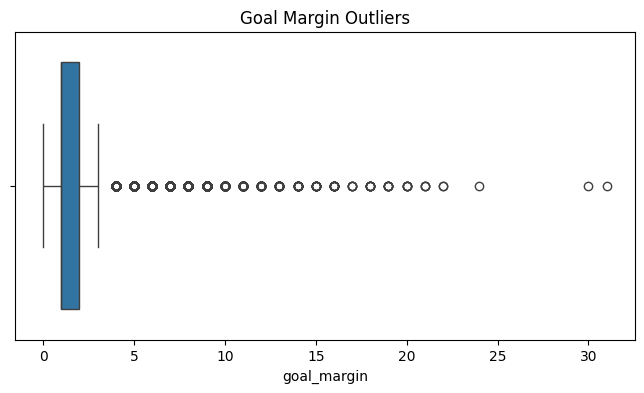

In [31]:

plt.figure(figsize=(8,4))
sns.boxplot(data= result ,x= "goal_margin")

plt.title("Goal Margin Outliers")

plt.show()

In [32]:
result.loc[
    result["goal_margin"].idxmax()
]

date                    2001-04-11 00:00:00
home_team                         Australia
away_team                    American Samoa
home_score                             31.0
away_score                              0.0
tournament     FIFA World Cup qualification
city                          Coffs Harbour
country                           Australia
neutral                               False
year                                   2001
decade                                 2000
total_goals                            31.0
goal_margin                            31.0
home_points                               3
away_points                               0
Name: 25425, dtype: object

### Outlier Detection and Handling

The goal margin was analyzed using the  boxplot to identify extreme matches.

Several matches were identified as outliers due to unusually large winning margins. However, these observations were retained because they represent real historical events rather than data entry errors. In sports analytics, such extreme results are meaningful and provide valuable insights into exceptional team performances.

In [33]:
# Goals scored as the home team
home_goals = result.groupby("home_team")["home_score"].sum()

# Goals scored as the away team
away_goals = result.groupby("away_team")["away_score"].sum()

# Combine goals from home and away matches
team_goals = home_goals.add(away_goals, fill_value=0)

# Convert to DataFrame
team_goals = (
    team_goals
    .sort_values(ascending=False)
    .reset_index()
)

team_goals.columns = ["Team", "Goals"]

team_goals.head(10)

,Team,Goals
0,England,2395.0
1,Germany,2331.0
2,Brazil,2315.0
3,Sweden,2178.0
4,Argentina,2047.0
5,Hungary,2011.0
6,Netherlands,1852.0
7,South Korea,1794.0
8,Mexico,1777.0
9,France,1731.0


In [34]:
# Merge shootouts with results

# We merge using:
# date + home_team + away_team
# because these columns uniquely identify each match

matches_shootouts = pd.merge(
    result,
    shoot,
    on=["date", "home_team", "away_team"],
    how="left"
)

In [35]:
# Merge goals with results

# Each goal becomes one row.
# A match with 5 goals will appear 5 times.
# This merged dataframe will be used ONLY
# for goal-related analysis (first scorer, comebacks, etc.)

matches_goals = pd.merge(
    result,
    goals,
    on=["date", "home_team", "away_team"],
    how="left"
)

In [36]:
print("Results shape:", result.shape)
print("Goals shape:", goals.shape)
print("Shootouts shape:", shoot.shape)

print("Matches + Shootouts:", matches_shootouts.shape)
print("Matches + Goals:", matches_goals.shape)

Results shape: (49518, 15)
Goals shape: (47814, 8)
Shootouts shape: (683, 5)
Matches + Shootouts: (49518, 17)
Matches + Goals: (81799, 20)


## Note: 
The three datasets were merged as needed for each analysis instead of creating one unified DataFrame. This approach avoids duplicating match records because goalscorers.csv stores one row per goal rather than one row per match, ensuring that match-level statistics remain accurate while still using information from all three datasets.

C:\Users\LeaderTech\AppData\Local\Temp\ipykernel_19012\195065100.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


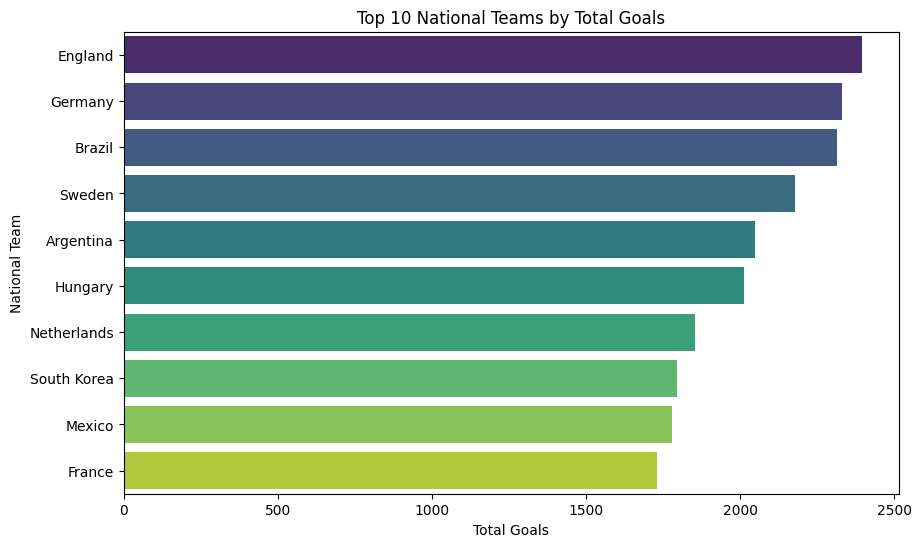

In [37]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=team_goals.head(10),
    x="Goals",
    y="Team",
    palette="viridis"
)

plt.title("Top 10 National Teams by Total Goals")
plt.xlabel("Total Goals")
plt.ylabel("National Team")

plt.show()

### Insight

The chart highlights the ten highest-scoring national teams in international football history.

England is the top one with 2395 goals

These teams have consistently participated in international competitions over many decades, allowing them to accumulate a large number of goals.

In [38]:
top_scorers = (
    goals["scorer"]
    .value_counts()
    .head(10)
    .reset_index()
)

top_scorers.columns = ["Player", "Goals"]

top_scorers

,Player,Goals
0,Cristiano Ronaldo,124
1,Harry Kane,75
2,Lionel Messi,71
3,Robert Lewandowski,68
4,Romelu Lukaku,67
5,Edin Džeko,58
6,Kylian Mbappé,53
7,Erling Haaland,53
8,Aleksandar Mitrović,52
9,Luis Suárez,51


C:\Users\LeaderTech\AppData\Local\Temp\ipykernel_19012\938588842.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


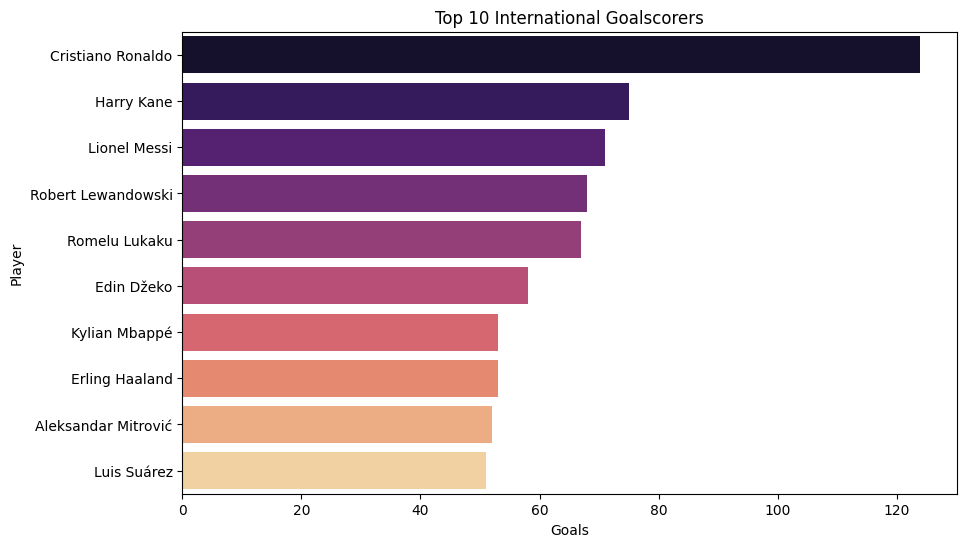

In [39]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_scorers,
    x="Goals",
    y="Player",
    palette="magma"
)

plt.title("Top 10 International Goalscorers")
plt.xlabel("Goals")
plt.ylabel("Player")

plt.show()

# Team Efficiency

In [40]:
team_stats = pd.DataFrame({
    "Team": pd.concat([
        result["home_team"],
        result["away_team"]
    ]).unique()
})

team_stats.head()

,Team
0,Scotland
1,England
2,Wales
3,Northern Ireland
4,United States


In [41]:
# Merge total goals into the team statistics table.

team_stats = team_stats.merge(
    team_goals,
    on="Team",
    how="left"
)

team_stats.head()

,Team,Goals
0,Scotland,1455.0
1,England,2395.0
2,Wales,910.0
3,Northern Ireland,741.0
4,United States,1211.0


In [42]:
home_matches = result["home_team"].value_counts()
away_matches = result["away_team"].value_counts()
matches = home_matches.add(away_matches, fill_value=0)
matches = matches.reset_index()
matches.columns = ["Team", "Matches"]



In [43]:
# Merge the total matches into the team statistics table.

team_stats = team_stats.merge(
    matches,
    on="Team",
    how="left"
)

In [44]:
# Sum the points earned when playing at home.

home_points = (
    result
    .groupby("home_team")["home_points"]
    .sum()
)


# Sum the points earned when playing away.

away_points = (
    result
    
    .groupby("away_team")["away_points"]
    .sum()
)

In [45]:
# Calculate the total points earned by each team.

points = home_points.add(
    away_points,
    fill_value=0
)

points = points.reset_index()
points.columns = ["Team", "Points"]

In [46]:
# Merge total points into the team statistics table.

team_stats = team_stats.merge(
    points,
    on="Team",
    how="left"
)


In [47]:
# Calculate the average goals scored per match.

team_stats["Goals_per_Match"] = (
    team_stats["Goals"] /
    team_stats["Matches"]
)

In [48]:
# Calculate the average points earned per match.

team_stats["Points_per_Match"] = (
    team_stats["Points"] /
    team_stats["Matches"]
)

In [49]:
# Keep only teams that played at least 100 matches.

team_stats = team_stats[
    team_stats["Matches"] > 100
]

In [50]:
team_stats.head()

,Team,Goals,Matches,Points,Goals_per_Match,Points_per_Match
0,Scotland,1455.0,854.0,1391.0,1.703747,1.628806
1,England,2395.0,1097.0,2149.0,2.183227,1.958979
2,Wales,910.0,726.0,867.0,1.253444,1.194215
3,Northern Ireland,741.0,707.0,715.0,1.048091,1.011315
4,United States,1211.0,795.0,1223.0,1.523270,1.538365


In [51]:
top_points = (
    team_stats
    .sort_values("Points", ascending=False)
    .head(10)
)

top_points

,Team,Goals,Matches,Points,Goals_per_Match,Points_per_Match
31,Brazil,2315.0,1064.0,2242.0,2.175752,2.107143
1,England,2395.0,1097.0,2149.0,2.183227,1.958979
8,Argentina,2047.0,1076.0,2054.0,1.902416,1.908922
19,Germany,2331.0,1035.0,2017.0,2.252174,1.948792
106,South Korea,1794.0,1010.0,1869.0,1.776238,1.850495
18,Sweden,2178.0,1105.0,1860.0,1.971041,1.683258
55,Mexico,1777.0,1008.0,1785.0,1.762897,1.770833
20,Italy,1565.0,893.0,1674.0,1.752520,1.874580
10,France,1731.0,942.0,1644.0,1.837580,1.745223
7,Hungary,2011.0,1006.0,1638.0,1.999006,1.628231


In [52]:
top_goals_per_match = (
    team_stats
    .sort_values("Goals_per_Match", ascending=False)
    .head(10)
)

top_goals_per_match

,Team,Goals,Matches,Points,Goals_per_Match,Points_per_Match
12,Jersey,645.0,235.0,479.0,2.744681,2.038298
114,Tahiti,657.0,242.0,424.0,2.714876,1.752066
109,New Caledonia,698.0,265.0,442.0,2.633962,1.667925
11,Guernsey,616.0,240.0,460.0,2.566667,1.916667
110,Fiji,608.0,268.0,396.0,2.268657,1.477612
19,Germany,2331.0,1035.0,2017.0,2.252174,1.948792
1,England,2395.0,1097.0,2149.0,2.183227,1.958979
31,Brazil,2315.0,1064.0,2242.0,2.175752,2.107143
169,Papua New Guinea,336.0,155.0,185.0,2.167742,1.193548
161,Solomon Islands,462.0,214.0,305.0,2.158879,1.425234


C:\Users\LeaderTech\AppData\Local\Temp\ipykernel_19012\1877367936.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


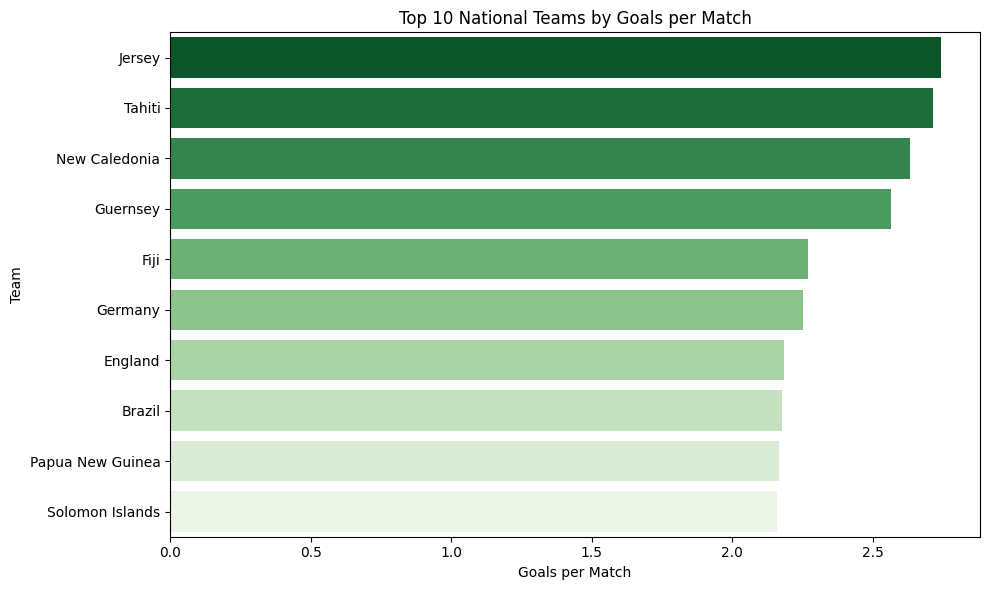

In [53]:
# Top 10 teams by goals scored per match

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_goals_per_match,
    x="Goals_per_Match",
    y="Team",
    palette="Greens_r"
)

plt.title("Top 10 National Teams by Goals per Match")
plt.xlabel("Goals per Match")
plt.ylabel("Team")

plt.tight_layout()
plt.show()

Several smaller national teams appear at the top of the ranking due to their high scoring averages. However, these results should be interpreted together with the total number of matches played.

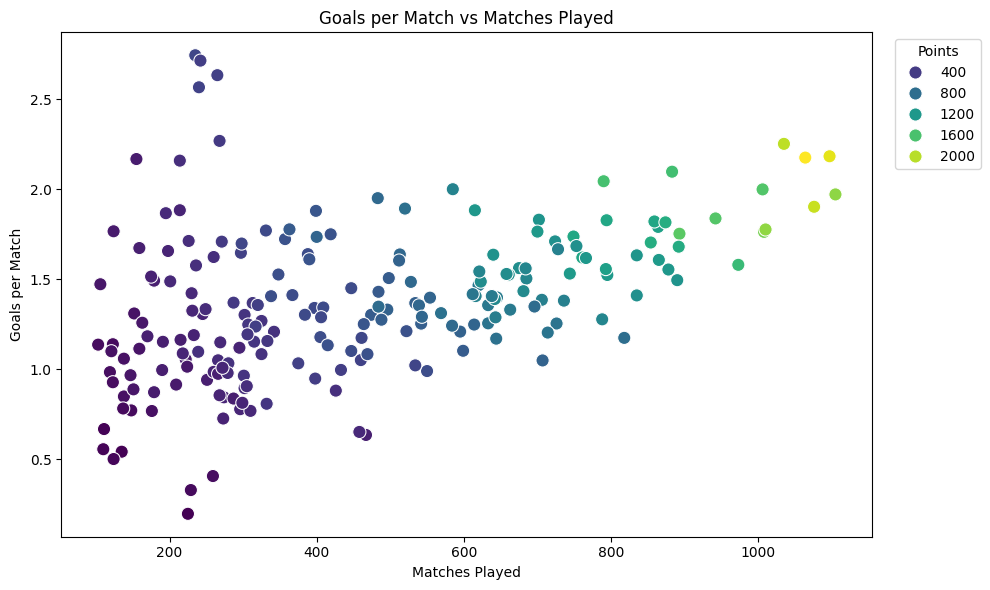

In [54]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=team_stats,
    x="Matches",
    y="Goals_per_Match",
    hue="Points",
    palette="viridis",
    s=90
)

plt.title("Goals per Match vs Matches Played")
plt.xlabel("Matches Played")
plt.ylabel("Goals per Match")

plt.legend(title="Points", bbox_to_anchor=(1.02,1), loc="upper left")

plt.tight_layout()
plt.show()

The scatter plot shows that teams with relatively few matches often have higher goal-scoring averages. In contrast, historically dominant teams have played many more matches while maintaining consistently strong scoring performance.

In [55]:
# Extract the year and decade from the match date.

shoot["year"] = shoot["date"].dt.year
shoot["decade"] = (shoot["year"] // 10) * 10

In [56]:
# Count the number of penalty shootouts in each decade.

shootouts_by_decade = (
    shoot
    .groupby("decade")
    .size()
    .reset_index(name="Shootouts")
)

shootouts_by_decade

,decade,Shootouts
0,1960,1
1,1970,38
2,1980,97
3,1990,126
4,2000,144
5,2010,153
6,2020,124


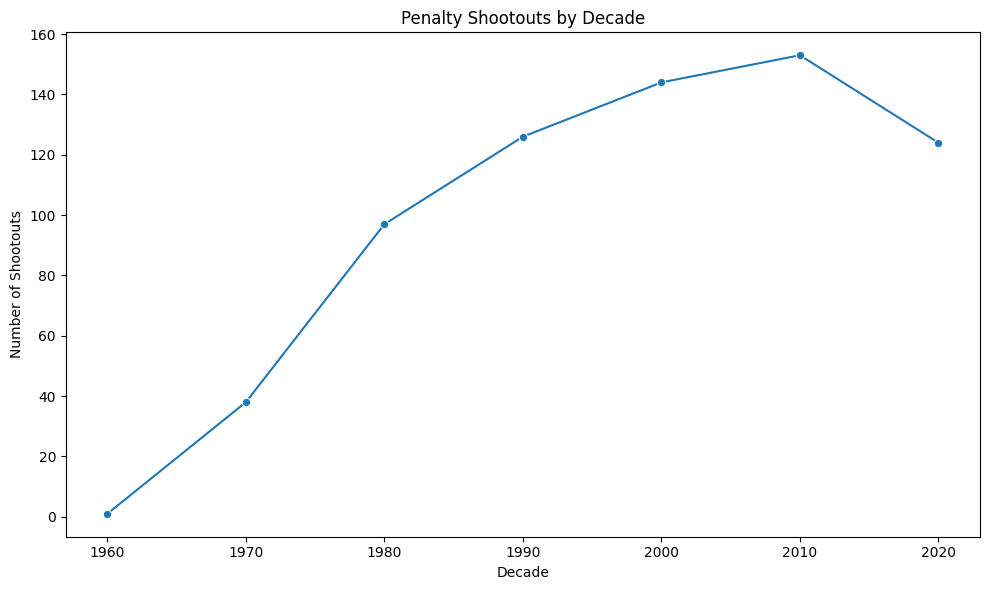

In [57]:
plt.figure(figsize=(10,6))

sns.lineplot(
    data=shootouts_by_decade,
    x="decade",
    y="Shootouts",
    marker="o"
)

plt.title("Penalty Shootouts by Decade")
plt.xlabel("Decade")
plt.ylabel("Number of Shootouts")

plt.tight_layout()
plt.show()

### Insight

The number of penalty shootouts increased steadily over the decades, reaching its highest level in the 2010s. This reflects the growing number of knockout competitions and the widespread use of penalty shootouts to determine winners.

The apparent decline in the 2020s should be interpreted with caution, as the current decade is still incomplete and contains only a few years of data.

In [58]:
tournament_shootouts = (
    matches_shootouts
    .dropna(subset=["winner"])      # only the matches which ended with shootouts
    ["tournament"]
    .value_counts()
    .head(10)
    .reset_index()
)

tournament_shootouts.columns = [
    "Tournament",
    "Shootouts"
]

tournament_shootouts

,Tournament,Shootouts
0,Friendly,79
1,COSAFA Cup,63
2,African Cup of Nations,47
3,FIFA World Cup,39
4,Copa América,33
5,African Cup of Nations qualification,28
6,AFC Asian Cup,27
7,UEFA Euro,25
8,FIFA World Cup qualification,21
9,Gold Cup,18


C:\Users\LeaderTech\AppData\Local\Temp\ipykernel_19012\439879397.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


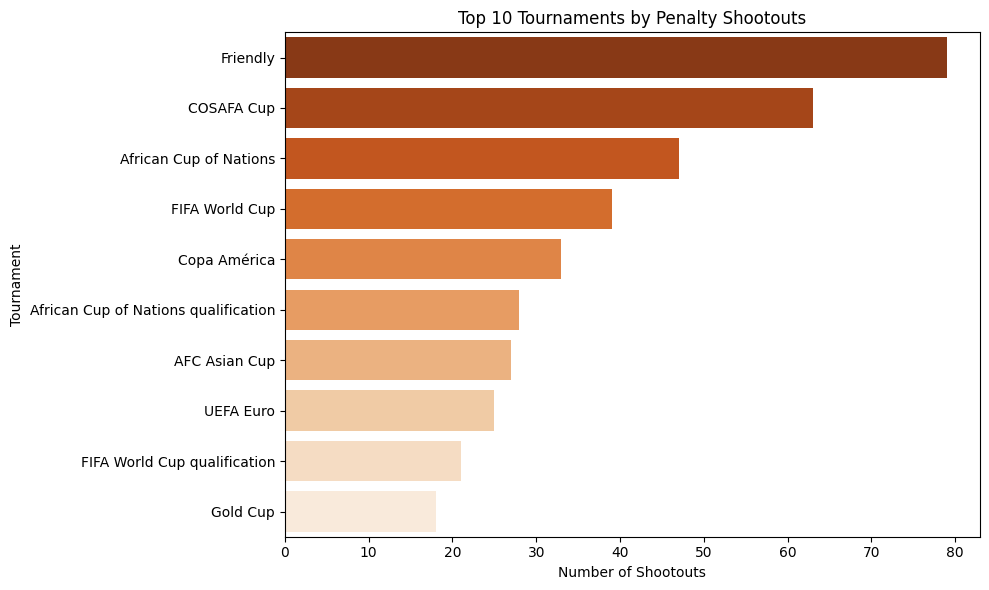

In [59]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=tournament_shootouts,
    x="Shootouts",
    y="Tournament",
    palette="Oranges_r"
)

plt.title("Top 10 Tournaments by Penalty Shootouts")
plt.xlabel("Number of Shootouts")
plt.ylabel("Tournament")

plt.tight_layout()
plt.show()

### Insight

Friendly matches recorded the highest number of penalty shootouts, followed by the COSAFA Cup and the African Cup of Nations. Among major international tournaments, the FIFA World Cup ranks fourth, reflecting the importance of penalty shootouts during knockout stages.
### Note

Although Friendly matches rank first, this does not necessarily mean they are more competitive than major tournaments. Some friendly competitions use penalty shootouts to determine a winner despite not being knockout tournaments, which increases their overall count.

In [60]:
# Keep only matches that have goal event data.
# Matches without recorded goals cannot be used
# to determine which team scored first.

matches_goals_valid = matches_goals.dropna(subset=["team"]).copy()

matches_goals_valid.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,year,decade,total_goals,goal_margin,home_points,away_points,team,scorer,minute,own_goal,penalty
479,1916-07-02,Chile,Uruguay,0.0,4.0,Copa América,Buenos Aires,Argentina,True,1916,1910,4.0,4.0,0,3,Uruguay,José Piendibene,44.0,False,False
480,1916-07-02,Chile,Uruguay,0.0,4.0,Copa América,Buenos Aires,Argentina,True,1916,1910,4.0,4.0,0,3,Uruguay,Isabelino Gradín,55.0,False,False
481,1916-07-02,Chile,Uruguay,0.0,4.0,Copa América,Buenos Aires,Argentina,True,1916,1910,4.0,4.0,0,3,Uruguay,Isabelino Gradín,70.0,False,False
482,1916-07-02,Chile,Uruguay,0.0,4.0,Copa América,Buenos Aires,Argentina,True,1916,1910,4.0,4.0,0,3,Uruguay,José Piendibene,75.0,False,False
484,1916-07-06,Argentina,Chile,6.0,1.0,Copa América,Buenos Aires,Argentina,False,1916,1910,7.0,5.0,3,0,Argentina,Alberto Ohaco,2.0,False,False


In [61]:
# Sort goals chronologically within each match.
# The earliest goal will appear first.

matches_goals_valid = matches_goals_valid.sort_values(
    by=["date", "home_team", "away_team", "minute"]
)

In [62]:
# Keep only the first goal from each match.

first_goals = matches_goals_valid.drop_duplicates(
    subset=["date", "home_team", "away_team"],
    keep="first"
)

first_goals.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,year,decade,total_goals,goal_margin,home_points,away_points,team,scorer,minute,own_goal,penalty
479,1916-07-02,Chile,Uruguay,0.0,4.0,Copa América,Buenos Aires,Argentina,True,1916,1910,4.0,4.0,0,3,Uruguay,José Piendibene,44.0,False,False
484,1916-07-06,Argentina,Chile,6.0,1.0,Copa América,Buenos Aires,Argentina,False,1916,1910,7.0,5.0,3,0,Argentina,Alberto Ohaco,2.0,False,False
491,1916-07-08,Brazil,Chile,1.0,1.0,Copa América,Buenos Aires,Argentina,True,1916,1910,2.0,0.0,1,1,Brazil,Demóstenes Correia de Syllos,29.0,False,False
493,1916-07-10,Argentina,Brazil,1.0,1.0,Copa América,Buenos Aires,Argentina,False,1916,1910,2.0,0.0,1,1,Argentina,José Durand Laguna,10.0,False,False
496,1916-07-12,Brazil,Uruguay,1.0,2.0,Copa América,Buenos Aires,Argentina,True,1916,1910,3.0,1.0,0,3,Brazil,Arthur Friedenreich,8.0,False,False


In [63]:
# Determine the winner of each match
# using the final score.

first_goals["winner"] = np.where(
    first_goals["home_score"] > first_goals["away_score"],
    first_goals["home_team"],
    np.where(
        first_goals["home_score"] < first_goals["away_score"],
        first_goals["away_team"],
        "Draw"
    )
)

C:\Users\LeaderTech\AppData\Local\Temp\ipykernel_19012\546124158.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  first_goals["winner"] = np.where(


In [64]:
# Keep only matches where the team that scored first
# did not win the match.

failed_matches = first_goals[
    first_goals["team"] != first_goals["winner"]
]

failed_matches.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,year,...,total_goals,goal_margin,home_points,away_points,team,scorer,minute,own_goal,penalty,winner
491,1916-07-08,Brazil,Chile,1.0,1.0,Copa América,Buenos Aires,Argentina,True,1916,...,2.0,0.0,1,1,Brazil,Demóstenes Correia de Syllos,29.0,False,False,Draw
493,1916-07-10,Argentina,Brazil,1.0,1.0,Copa América,Buenos Aires,Argentina,False,1916,...,2.0,0.0,1,1,Argentina,José Durand Laguna,10.0,False,False,Draw
496,1916-07-12,Brazil,Uruguay,1.0,2.0,Copa América,Buenos Aires,Argentina,True,1916,...,3.0,1.0,0,3,Brazil,Arthur Friedenreich,8.0,False,False,Uruguay
532,1917-10-03,Argentina,Brazil,4.0,2.0,Copa América,Montevideo,Uruguay,True,1917,...,6.0,2.0,3,0,Brazil,Neco,8.0,False,False,Argentina
605,1919-05-26,Brazil,Uruguay,2.0,2.0,Copa América,Rio de Janeiro,Brazil,False,1919,...,4.0,0.0,1,1,Uruguay,Isabelino Gradín,13.0,False,False,Draw


In [65]:
# Count how many times each team
# scored first but failed to win.

worst_performers = (
    failed_matches["team"]
    .value_counts()
    .head(10)
    .reset_index()
)

worst_performers.columns = [
    "Team",
    "Failed_to_Win"
]

worst_performers

,Team,Failed_to_Win
0,Brazil,57
1,Switzerland,54
2,Uruguay,52
3,Sweden,51
4,Republic of Ireland,50
5,Denmark,49
6,Spain,49
7,Belgium,48
8,Paraguay,48
9,Poland,47


C:\Users\LeaderTech\AppData\Local\Temp\ipykernel_19012\2657611584.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


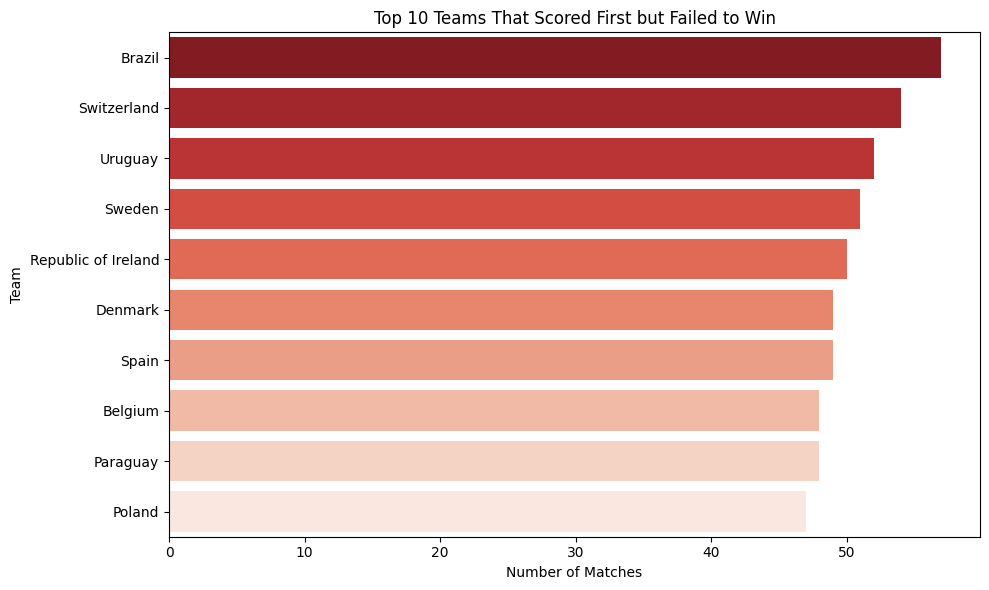

In [66]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=worst_performers,
    x="Failed_to_Win",
    y="Team",
    palette="Reds_r"
)

plt.title("Top 10 Teams That Scored First but Failed to Win")
plt.xlabel("Number of Matches")
plt.ylabel("Team")

plt.tight_layout()
plt.show()

### Insight

The results show the teams that most frequently score the opening goal but fail to convert that advantage into a victory. This suggests that taking an early lead does not always guarantee success, as some teams struggle to maintain their advantage or are vulnerable to comebacks by their opponents.

In [67]:
# Create a new column indicating whether the match ended in a draw.
# True = Draw, False = Win/Loss

result["is_draw"] = (
    result["home_score"] == result["away_score"]
)

In [68]:
# Group matches by decade and calculate
# the required statistics.

era_stats = (
    result
    .groupby("decade")
    .agg(
        Avg_Goals=("total_goals", "mean"),
        Avg_Goal_Margin=("goal_margin", "mean"),
        Draw_Rate=("is_draw", "mean")
    )
    .reset_index()
)

In [69]:
# Convert draw rate from decimal to percentage.

era_stats["Draw_Rate"] *= 100

era_stats = era_stats.round(2)

era_stats

,decade,Avg_Goals,Avg_Goal_Margin,Draw_Rate
0,1870,4.54,2.54,15.38
1,1880,5.58,3.84,9.09
2,1890,5.15,3.08,15.25
3,1900,4.16,2.29,17.39
4,1910,4.22,2.33,16.06
5,1920,3.88,2.07,17.93
6,1930,4.32,2.09,15.94
7,1940,4.34,2.41,15.37
8,1950,4.00,2.02,18.35
9,1960,3.48,1.91,19.62


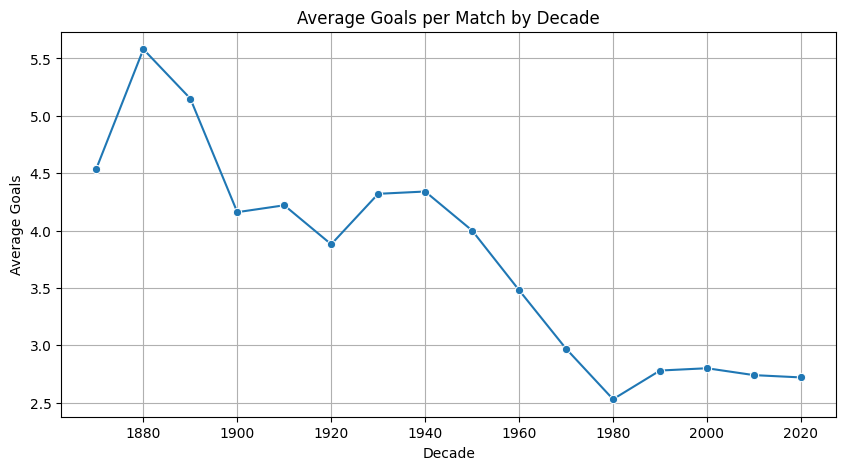

In [70]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=era_stats,
    x="decade",
    y="Avg_Goals",
    marker="o"
)

plt.title("Average Goals per Match by Decade")
plt.xlabel("Decade")
plt.ylabel("Average Goals")

plt.grid(True)
plt.show()

The average number of goals per match was highest during the late 19th century, exceeding 5 goals per game in some decades. Since then, scoring has gradually declined, reaching around 2.7 goals per match in recent decades. This suggests that modern football has become more tactically organized and defensively balanced compared to its early years.

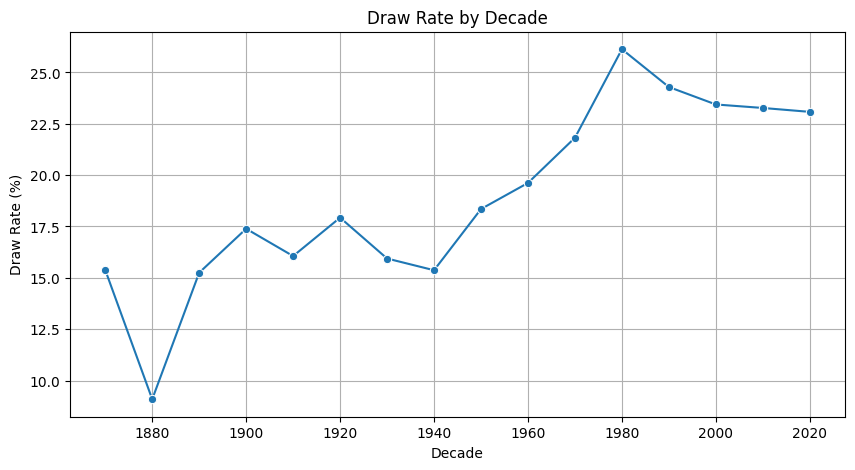

In [71]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=era_stats,
    x="decade",
    y="Draw_Rate",
    marker="o"
)

plt.title("Draw Rate by Decade")
plt.xlabel("Decade")
plt.ylabel("Draw Rate (%)")

plt.grid(True)
plt.show()

The percentage of drawn matches has generally increased over time. While draws were relatively uncommon in the early decades of international football, they became more frequent from the 1950s onward, peaking around the 1980s. This indicates that modern international matches tend to be more evenly contested.

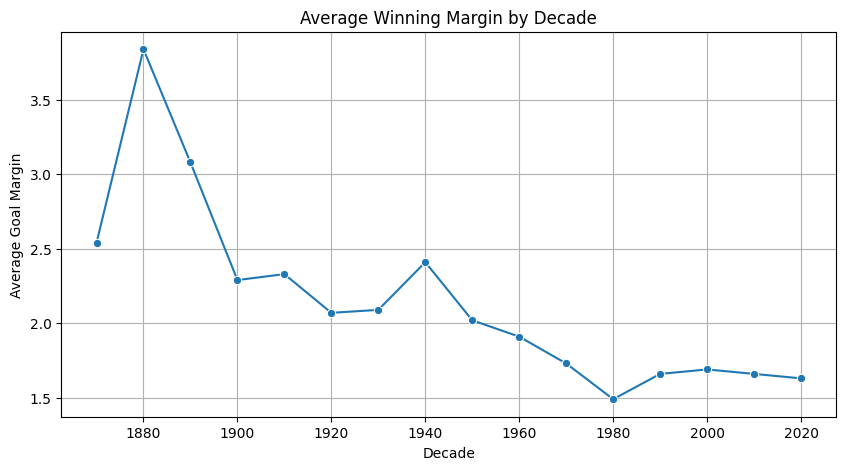

In [72]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=era_stats,
    x="decade",
    y="Avg_Goal_Margin",
    marker="o"
)

plt.title("Average Winning Margin by Decade")
plt.xlabel("Decade")
plt.ylabel("Average Goal Margin")

plt.grid(True)
plt.show()

The average winning margin has steadily decreased throughout football history. Early international matches often ended with large score differences, whereas recent decades show much smaller margins, suggesting that the gap between national teams has narrowed and competitions have become more balanced.

# Final Report

## Project Summary

This project analyzed more than 150 years of international football history using the International Football Results (1872–2024) dataset. Three datasets (results, goalscorers, and shootouts) were used to investigate historical team performance, scoring trends, player achievements, penalty shootouts, and the evolution of football over time.

---

## Data Preparation

Several preprocessing steps were performed before the analysis:

- Converted date columns to datetime format.
- Standardized historical country names.
- Handled missing values appropriately.
- Merged datasets whenever additional information was required.
- Engineered new features including:
  - Year
  - Decade
  - Total Goals
  - Goal Margin
  - Match Points

---

## Analysis Performed

The following analyses were completed:

### Top Performers
Identified the ten highest-scoring national teams and the top international goalscorers in football history.

### Team Efficiency
Compared national teams using goals per match and points per match. A minimum match threshold was applied to ensure fair comparisons between teams with different numbers of matches.

### Drama Analysis
Investigated penalty shootouts across different decades and tournaments to determine where they occur most frequently.

### Worst Performers
Identified teams that frequently score the opening goal but still fail to win the match, highlighting teams that struggle to maintain an early advantage.

### Era Comparison
Compared goals per match, draw rates, and winning margins across decades to understand how international football has evolved since 1872.

---

# Key Insights

- England, Brazil, Germany, and Argentina consistently rank among the strongest national teams across multiple performance metrics.
- Applying a minimum match threshold produces a more reliable ranking of team efficiency.
- Penalty shootouts have become increasingly common in modern football.
- Some teams regularly lose matches despite scoring first, indicating weaknesses in maintaining leads.
- International football has become more balanced over time, with lower scoring rates, smaller winning margins, and a higher proportion of drawn matches.

---

# Recommendations

- Evaluate teams using efficiency metrics in addition to total statistics.
- Apply minimum participation thresholds when comparing national teams.
- Analyze matches where teams lose after scoring first to improve tactical decision-making.
- Continue monitoring long-term trends to understand how football strategies evolve over time.
- Future work could include FIFA rankings, player statistics, expected goals (xG), and machine learning models for match prediction.

---

# Conclusion

This project demonstrates how historical football data can be transformed into meaningful insights through data cleaning, feature engineering, statistical analysis, and visualization. The results provide a comprehensive overview of team performance, competitive balance, and the evolution of international football over more than a century.